In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()


,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE",axis=1)
y=df["PE"]

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [9]:
df.shape

(9568, 5)

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [12]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [13]:
import torch
import torch.nn as nn

In [14]:
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)


In [15]:
type(X_train_scaled)

numpy.ndarray

In [16]:
type(y_test)
y_train.shape

(7654,)

In [17]:
y_train

5487    442.75
3522    432.52
6916    428.80
7544    426.07
7600    436.58
         ...  
5734    436.44
5191    441.20
5390    464.26
860     440.45
7270    484.44
Name: PE, Length: 7654, dtype: float64

In [18]:
from torch.utils.data import TensorDataset ,DataLoader

In [19]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [20]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)


# Deep learning


In [21]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [22]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ANN(nn.Module):
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [24]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 206194.4251953125 & val loss = 204951.21875
epoch 2/100 ==> train loss = 201274.6685546875 & val loss = 194830.203125
epoch 3/100 ==> train loss = 182875.8142578125 & val loss = 167964.046875
epoch 4/100 ==> train loss = 148885.70120442708 & val loss = 129313.59375
epoch 5/100 ==> train loss = 110045.35152994792 & val loss = 92947.703125
epoch 6/100 ==> train loss = 78969.15071614583 & val loss = 68114.546875
epoch 7/100 ==> train loss = 59111.286442057295 & val loss = 51767.08984375
epoch 8/100 ==> train loss = 44449.14070638021 & val loss = 38072.1328125
epoch 9/100 ==> train loss = 31612.857535807292 & val loss = 26099.25390625
epoch 10/100 ==> train loss = 20993.598341878256 & val loss = 16689.70703125
epoch 11/100 ==> train loss = 13221.101037597657 & val loss = 10183.671875
epoch 12/100 ==> train loss = 8040.750624593099 & val loss = 6200.8115234375
epoch 13/100 ==> train loss = 5077.168494669596 & val loss = 3998.133544921875
epoch 14/100 ==> train l

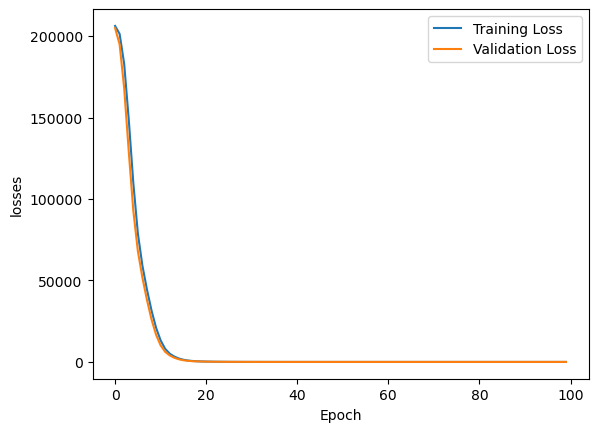

In [25]:
import matplotlib.pyplot as plt 

loss_df=pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"],label="Training Loss")

plt.plot(loss_df["Validation Loss"],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("losses")

plt.legend ()

In [26]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [27]:
model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)

    train_mse_loss=crietrion( train_preds,y_train_tensor)
    test_mse_loss=crietrion( train_preds,y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Training MSE:",test_mse_loss.item())

C:\Users\Dell Latitude\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1914, 1])) that is different to the input size (torch.Size([7654, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (7654) must match the size of tensor b (1914) at non-singleton dimension 0